# Week 1 — Role C: Exploratory Data Analysis (EDA)

**Objectives:**
1. Identify the number of observations in each raw dataset
2. Identify missing values per column
3. Plot the baseline distribution of flight delays

**Data Sources:**
- BTS On-Time Performance (Feb 2022 – Jan 2025 sample) — downloaded directly
- Open-Meteo Historical Weather API — fetched via free API
- FAA ASPM Airport Congestion — loaded from local CSV if available

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
import os
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Local cache directory so we don't re-download every run
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. BTS On-Time Performance Data

We download a few months of BTS data directly from the TranStats pre-zipped archives.
Each zip contains a single CSV with all domestic flight records for that month.

In [2]:
def download_bts_month(year: int, month: int) -> pd.DataFrame:
    """Download one month of BTS On-Time Performance data."""
    cache_path = CACHE_DIR / f"bts_{year}_{month}.parquet"
    if cache_path.exists():
        print(f"  Loading cached {year}-{month:02d}")
        return pd.read_parquet(cache_path)

    url = (
        f"https://transtats.bts.gov/PREZIP/"
        f"On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip"
    )
    print(f"  Downloading {year}-{month:02d} from BTS ...")
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
        with zf.open(csv_name) as f:
            df = pd.read_csv(f, low_memory=False)

    df.to_parquet(cache_path, index=False)
    return df


# Pull a representative sample: 3 months across different seasons
# Adjust these if you want more coverage
SAMPLE_MONTHS = [
    (2024, 1),   # winter
    (2024, 7),   # summer
    (2024, 10),  # fall
]

bts_frames = []
for year, month in SAMPLE_MONTHS:
    try:
        df = download_bts_month(year, month)
        bts_frames.append(df)
        print(f"  -> {len(df):,} rows")
    except Exception as e:
        print(f"  -> FAILED: {e}")

bts = pd.concat(bts_frames, ignore_index=True)
print(f"\nTotal BTS rows: {len(bts):,}")
print(f"Columns: {len(bts.columns)}")

  -> FAILED: ('Connection broken: IncompleteRead(19136512 bytes read, 8436753 more expected)', IncompleteRead(19136512 bytes read, 8436753 more expected))
  -> 634,613 rows
  -> 615,497 rows

Total BTS rows: 1,250,110
Columns: 110


### 1.1 Number of Observations

In [3]:
print(f"BTS On-Time Performance")
print(f"  Rows : {len(bts):,}")
print(f"  Cols : {len(bts.columns)}")
print(f"  Date range: {bts['FlightDate'].min()} to {bts['FlightDate'].max()}")
print(f"  Unique airlines: {bts['Reporting_Airline'].nunique()}")
print(f"  Unique origin airports: {bts['Origin'].nunique()}")
print(f"  Unique dest airports: {bts['Dest'].nunique()}")
bts.head()

BTS On-Time Performance
  Rows : 1,250,110
  Cols : 110
  Date range: 2024-07-01 to 2024-10-31
  Unique airlines: 15
  Unique origin airports: 343
  Unique dest airports: 343


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2024,3,7,1,1,2024-07-01,9E,20363,9E,N935XJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,3,7,2,2,2024-07-02,9E,20363,9E,N335PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,3,7,3,3,2024-07-03,9E,20363,9E,N337PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,3,7,4,4,2024-07-04,9E,20363,9E,N272PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,3,7,5,5,2024-07-05,9E,20363,9E,N146PQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Missing Values

Missing values in key BTS columns:
                                 missing_count  missing_pct
CancellationCode                       1225454        98.03
NASDelay                                987904        79.03
WeatherDelay                            987904        79.03
ArrDelay                                 27658         2.21
ArrDelayMinutes                          27658         2.21
ArrTime                                  24817         1.99
DepTime                                  24024         1.92
DepDelay                                 24059         1.92
DepDelayMinutes                          24059         1.92
FlightDate                                   0         0.00
CRSDepTime                                   0         0.00
Origin                                       0         0.00
Dest                                         0         0.00
Reporting_Airline                            0         0.00
Flight_Number_Reporting_Airline              0         0.00
CRSAr

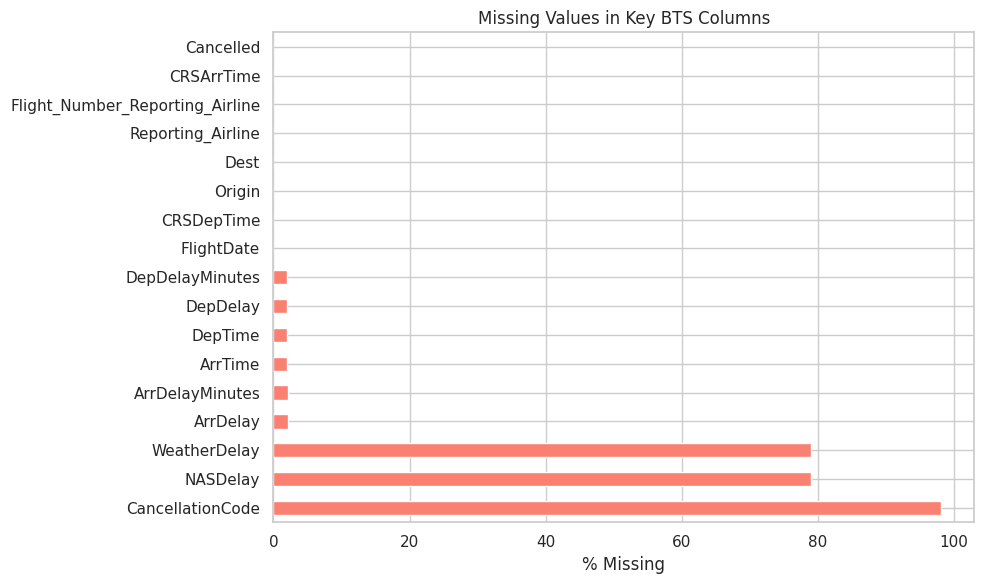

In [4]:
# Key columns from our ERD
KEY_BTS_COLS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest",
    "CRSDepTime", "DepTime", "DepDelay", "DepDelayMinutes",
    "CRSArrTime", "ArrTime", "ArrDelay", "ArrDelayMinutes",
    "Cancelled", "CancellationCode",
    "WeatherDelay", "NASDelay",
]

# Only use columns that actually exist in the data
available_cols = [c for c in KEY_BTS_COLS if c in bts.columns]

missing = bts[available_cols].isnull().sum()
missing_pct = (missing / len(bts) * 100).round(2)

missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df.sort_values("missing_pct", ascending=False)
print("Missing values in key BTS columns:")
print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
missing_df["missing_pct"].plot.barh(ax=ax, color="salmon")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values in Key BTS Columns")
plt.tight_layout()
plt.show()

### 1.3 Baseline Distribution of Delays

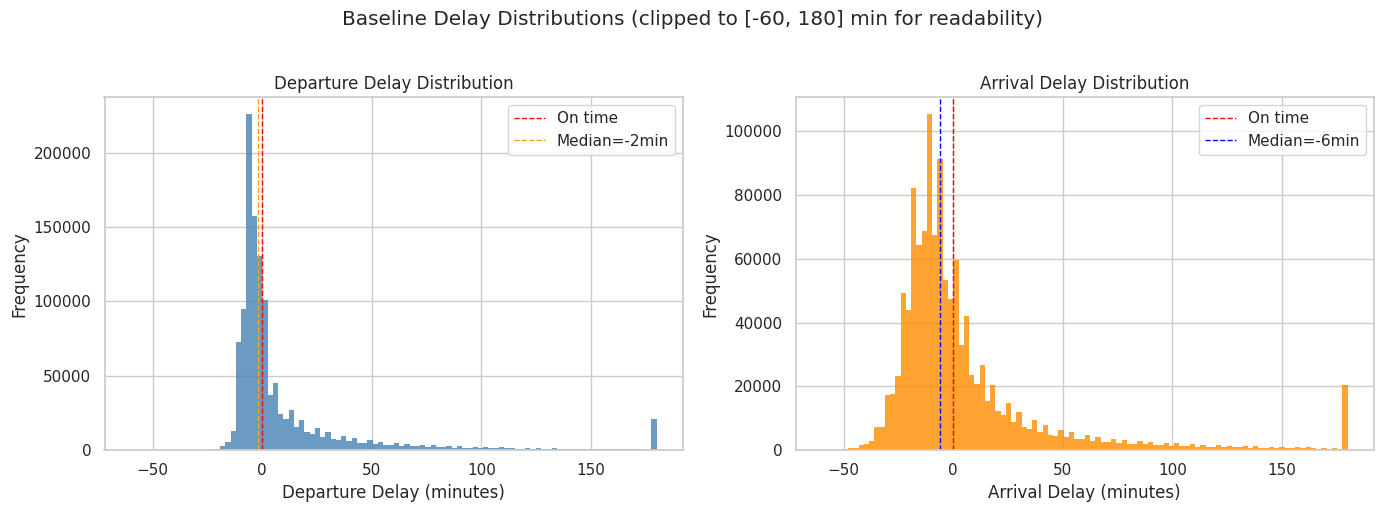

Departure Delay Stats (minutes):
count    1.226051e+06
mean     1.394696e+01
std      5.792067e+01
min     -6.600000e+01
25%     -6.000000e+00
50%     -2.000000e+00
75%      1.000000e+01
max      3.777000e+03

% flights delayed >15 min: 20.9%
% flights delayed >60 min: 8.0%

Arrival Delay Stats (minutes):
count    1.222452e+06
mean     8.447778e+00
std      5.958205e+01
min     -9.100000e+01
25%     -1.500000e+01
50%     -6.000000e+00
75%      1.000000e+01
max      3.803000e+03

% flights delayed >15 min: 20.8%
% flights delayed >60 min: 7.9%


In [5]:
# --- Departure Delay Distribution ---
dep_col = "DepDelay"
arr_col = "ArrDelay"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Departure delay
dep_delay = bts[dep_col].dropna()
dep_delay_clipped = dep_delay.clip(-60, 180)  # clip for readability
axes[0].hist(dep_delay_clipped, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="On time")
axes[0].axvline(dep_delay.median(), color="orange", linestyle="--", linewidth=1, label=f"Median={dep_delay.median():.0f}min")
axes[0].set_xlabel("Departure Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Departure Delay Distribution")
axes[0].legend()

# Arrival delay
arr_delay = bts[arr_col].dropna()
arr_delay_clipped = arr_delay.clip(-60, 180)
axes[1].hist(arr_delay_clipped, bins=100, color="darkorange", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="On time")
axes[1].axvline(arr_delay.median(), color="blue", linestyle="--", linewidth=1, label=f"Median={arr_delay.median():.0f}min")
axes[1].set_xlabel("Arrival Delay (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Arrival Delay Distribution")
axes[1].legend()

plt.suptitle("Baseline Delay Distributions (clipped to [-60, 180] min for readability)", y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("Departure Delay Stats (minutes):")
print(dep_delay.describe().to_string())
print(f"\n% flights delayed >15 min: {(dep_delay > 15).mean() * 100:.1f}%")
print(f"% flights delayed >60 min: {(dep_delay > 60).mean() * 100:.1f}%")

print("\nArrival Delay Stats (minutes):")
print(arr_delay.describe().to_string())
print(f"\n% flights delayed >15 min: {(arr_delay > 15).mean() * 100:.1f}%")
print(f"% flights delayed >60 min: {(arr_delay > 60).mean() * 100:.1f}%")

Overall cancellation rate: 1.97%
Cancelled flights: 24,656 / 1,250,110


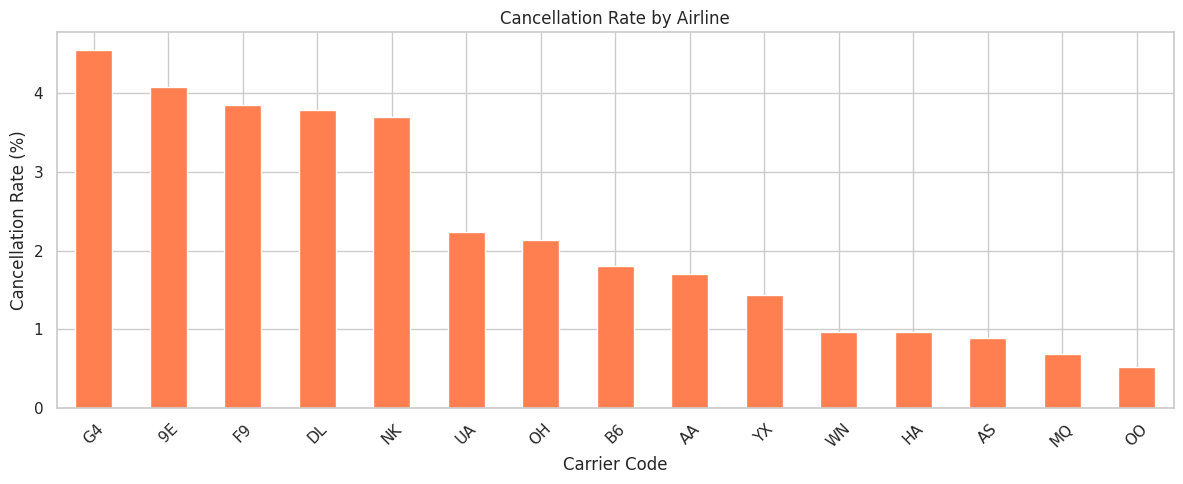

                   cancel_rate  cancelled   total
Reporting_Airline                                
G4                        4.55     1003.0   22056
9E                        4.08     1390.0   34098
F9                        3.85     1433.0   37233
DL                        3.79     6852.0  180596
NK                        3.70     1699.0   45945
UA                        2.24     3003.0  133866
OH                        2.13      877.0   41224
B6                        1.81      723.0   39876
AA                        1.70     2974.0  175103
YX                        1.43      753.0   52772
WN                        0.97     2395.0  246893
HA                        0.96      128.0   13403
AS                        0.89      394.0   44387
MQ                        0.69      344.0   49675
OO                        0.52      688.0  132983


In [6]:
# --- Cancellation Rate ---
if "Cancelled" in bts.columns:
    cancel_rate = bts["Cancelled"].mean() * 100
    print(f"Overall cancellation rate: {cancel_rate:.2f}%")
    print(f"Cancelled flights: {bts['Cancelled'].sum():,.0f} / {len(bts):,}")

    # Cancellation by carrier
    cancel_by_carrier = (
        bts.groupby("Reporting_Airline")["Cancelled"]
        .agg(["mean", "sum", "count"])
        .rename(columns={"mean": "cancel_rate", "sum": "cancelled", "count": "total"})
        .sort_values("cancel_rate", ascending=False)
    )
    cancel_by_carrier["cancel_rate"] = (cancel_by_carrier["cancel_rate"] * 100).round(2)

    fig, ax = plt.subplots(figsize=(12, 5))
    cancel_by_carrier["cancel_rate"].plot.bar(ax=ax, color="coral")
    ax.set_ylabel("Cancellation Rate (%)")
    ax.set_title("Cancellation Rate by Airline")
    ax.set_xlabel("Carrier Code")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(cancel_by_carrier.to_string())

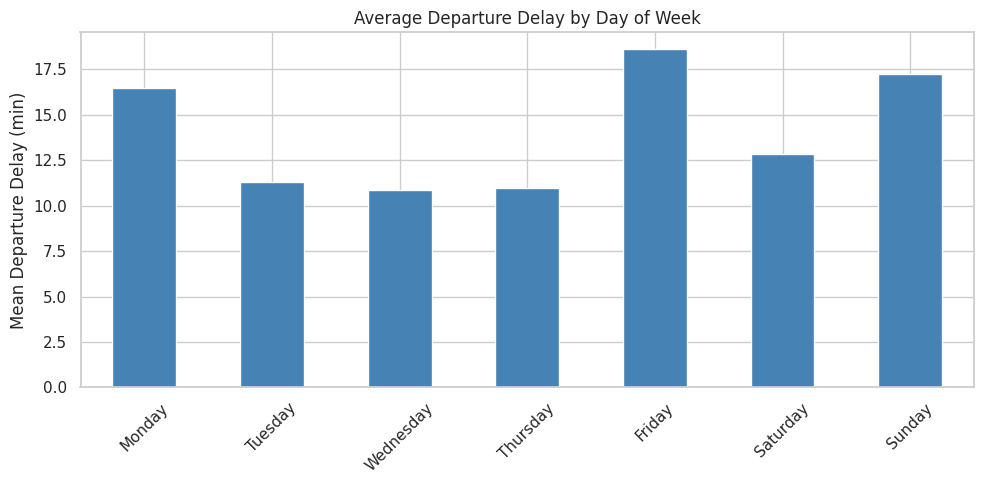

In [7]:
# --- Delay by Day of Week ---
bts["FlightDate_PARSED"] = pd.to_datetime(bts["FlightDate"])
bts["day_of_week"] = bts["FlightDate_PARSED"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_delay = (
    bts.groupby("day_of_week")[dep_col]
    .mean()
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(10, 5))
daily_delay.plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("Mean Departure Delay (min)")
ax.set_title("Average Departure Delay by Day of Week")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

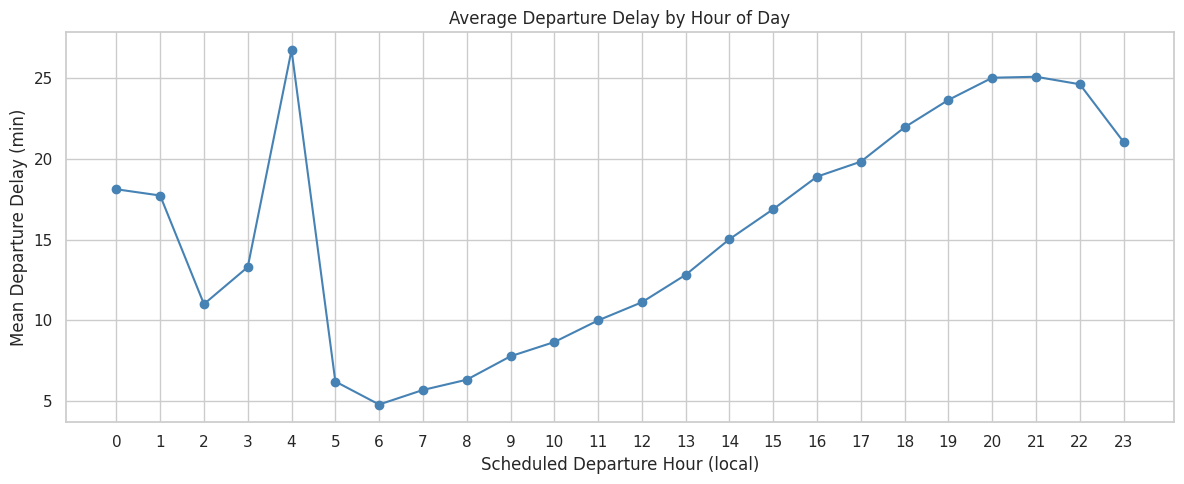

In [8]:
# --- Delay by Time of Day ---
if "CRSDepTime" in bts.columns:
    bts["dep_hour"] = (bts["CRSDepTime"] // 100).clip(0, 23).astype(int)

    hourly_delay = bts.groupby("dep_hour")[dep_col].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    hourly_delay.plot(ax=ax, marker="o", color="steelblue")
    ax.set_xlabel("Scheduled Departure Hour (local)")
    ax.set_ylabel("Mean Departure Delay (min)")
    ax.set_title("Average Departure Delay by Hour of Day")
    ax.set_xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

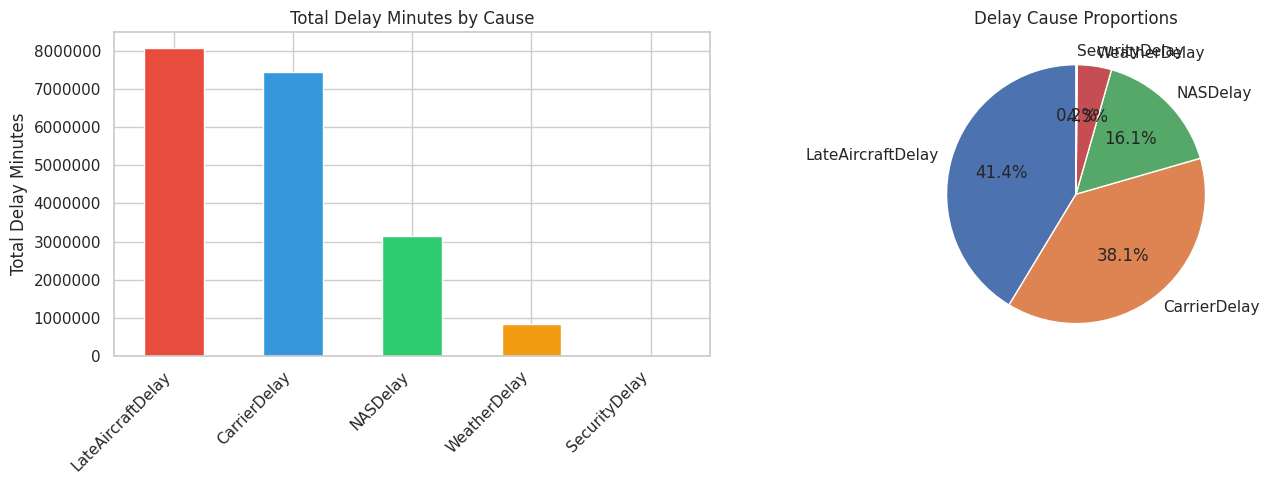

Total delay minutes by cause:
LateAircraftDelay    8084128.0
CarrierDelay         7452879.0
NASDelay             3148011.0
WeatherDelay          835366.0
SecurityDelay          29723.0


In [9]:
# --- Weather & NAS Delay Breakdown ---
delay_cause_cols = [c for c in ["WeatherDelay", "NASDelay", "SecurityDelay",
                                 "LateAircraftDelay", "CarrierDelay"] if c in bts.columns]

if delay_cause_cols:
    cause_totals = bts[delay_cause_cols].sum().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart of total delay minutes by cause
    cause_totals.plot.bar(ax=axes[0], color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"][:len(cause_totals)])
    axes[0].set_ylabel("Total Delay Minutes")
    axes[0].set_title("Total Delay Minutes by Cause")
    axes[0].ticklabel_format(style="plain", axis="y")
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

    # Pie chart
    cause_totals.plot.pie(ax=axes[1], autopct="%1.1f%%", startangle=90)
    axes[1].set_ylabel("")
    axes[1].set_title("Delay Cause Proportions")

    plt.tight_layout()
    plt.show()

    print("Total delay minutes by cause:")
    print(cause_totals.to_string())
else:
    print("Delay cause columns not found in dataset.")

---
## 2. Open-Meteo Weather Data

In [10]:
# Top 10 busiest US airports by passenger volume
AIRPORTS = {
    "ATL": {"lat": 33.6407, "lon": -84.4277},
    "DFW": {"lat": 32.8998, "lon": -97.0403},
    "DEN": {"lat": 39.8561, "lon": -104.6737},
    "ORD": {"lat": 41.9742, "lon": -87.9073},
    "LAX": {"lat": 33.9416, "lon": -118.4085},
    "JFK": {"lat": 40.6413, "lon": -73.7781},
    "SFO": {"lat": 37.6213, "lon": -122.3790},
    "SEA": {"lat": 47.4502, "lon": -122.3088},
    "LAS": {"lat": 36.0840, "lon": -115.1537},
    "MCO": {"lat": 28.4312, "lon": -81.3081},
}

def fetch_weather(airport_code: str, start: str, end: str) -> pd.DataFrame:
    """Fetch hourly weather from Open-Meteo Historical API."""
    coords = AIRPORTS[airport_code]
    params = {
        "latitude": coords["lat"],
        "longitude": coords["lon"],
        "start_date": start,
        "end_date": end,
        "hourly": "temperature_2m,wind_speed_10m,precipitation,cloudcover,cloudcover_low",
        "wind_speed_unit": "kn",
        "timezone": "UTC",
    }
    resp = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=60)
    resp.raise_for_status()
    hourly = resp.json()["hourly"]
    df = pd.DataFrame(hourly)
    df["airport_code"] = airport_code
    return df


# Fetch one representative month of weather for all airports
WEATHER_START = "2024-07-01"
WEATHER_END = "2024-07-31"

cache_weather = CACHE_DIR / "weather_sample.parquet"
if cache_weather.exists():
    weather = pd.read_parquet(cache_weather)
    print(f"Loaded cached weather: {len(weather):,} rows")
else:
    weather_frames = []
    for code in AIRPORTS:
        print(f"  Fetching {code} ...")
        try:
            wdf = fetch_weather(code, WEATHER_START, WEATHER_END)
            weather_frames.append(wdf)
        except Exception as e:
            print(f"    FAILED: {e}")
    weather = pd.concat(weather_frames, ignore_index=True)
    weather.to_parquet(cache_weather, index=False)
    print(f"\nTotal weather rows: {len(weather):,}")

Loaded cached weather: 7,440 rows


In [11]:
print(f"Weather Data")
print(f"  Rows: {len(weather):,}")
print(f"  Columns: {list(weather.columns)}")
print(f"  Airports: {weather['airport_code'].unique().tolist()}")
print(f"  Time range: {weather['time'].min()} to {weather['time'].max()}")

# Missing values
weather_missing = weather.isnull().sum()
weather_missing_pct = (weather_missing / len(weather) * 100).round(2)
print("\nMissing values:")
print(pd.DataFrame({"count": weather_missing, "pct": weather_missing_pct}).to_string())

Weather Data
  Rows: 7,440
  Columns: ['time', 'temperature_2m', 'wind_speed_10m', 'precipitation', 'cloudcover', 'cloudcover_low', 'airport_code']
  Airports: ['ATL', 'DFW', 'DEN', 'ORD', 'LAX', 'JFK', 'SFO', 'SEA', 'LAS', 'MCO']
  Time range: 2024-07-01T00:00 to 2024-07-31T23:00

Missing values:
                count  pct
time                0  0.0
temperature_2m      0  0.0
wind_speed_10m      0  0.0
precipitation       0  0.0
cloudcover          0  0.0
cloudcover_low      0  0.0
airport_code        0  0.0


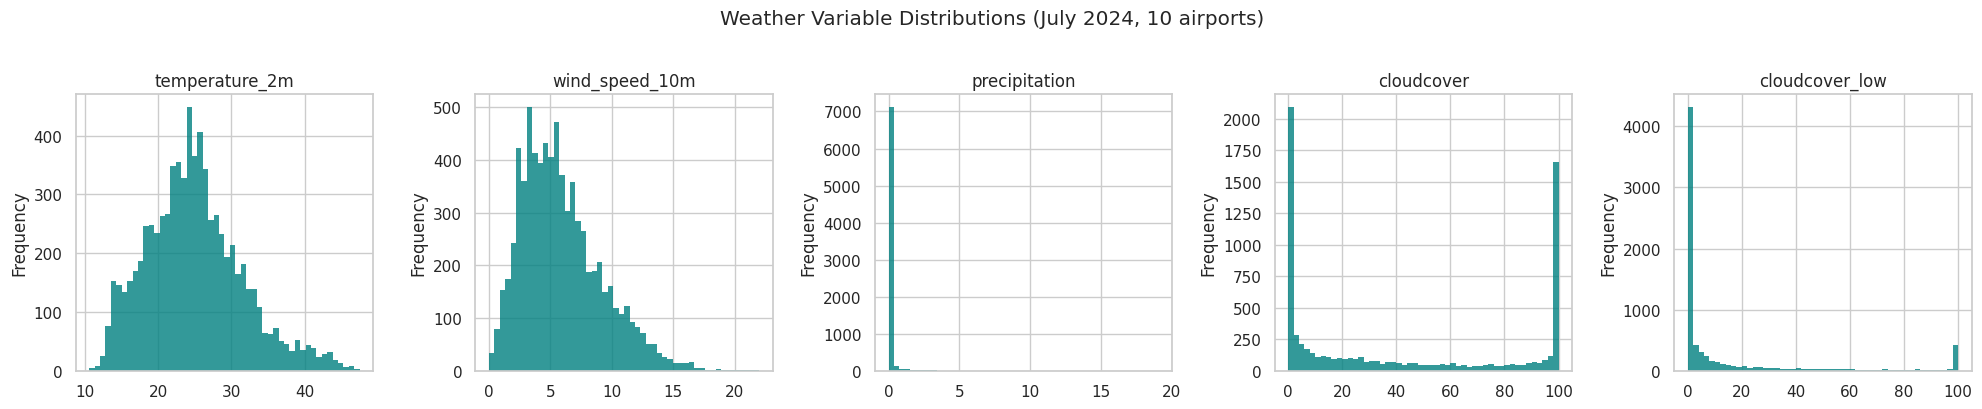

In [12]:
# Weather variable distributions
weather_vars = ["temperature_2m", "wind_speed_10m", "precipitation", "cloudcover", "cloudcover_low"]
available_weather = [c for c in weather_vars if c in weather.columns]

fig, axes = plt.subplots(1, len(available_weather), figsize=(4 * len(available_weather), 4))
if len(available_weather) == 1:
    axes = [axes]

for ax, col in zip(axes, available_weather):
    weather[col].dropna().hist(bins=50, ax=ax, color="teal", edgecolor="none", alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Weather Variable Distributions (July 2024, 10 airports)", y=1.02)
plt.tight_layout()
plt.show()

---
## 3. FAA ASPM Airport Congestion Data

ASPM data must be **manually downloaded** from the FAA website:  
https://www.aspm.faa.gov/apm/sys/AnalysisAP.asp  

If Role B has already extracted ASPM data, place the CSV(s) in `../extract/input/aspm/` and this section will pick them up automatically.

In [13]:
aspm_dir = Path("../extract/input/aspm")
aspm_output = Path("../extract/output/aspm_raw_combined.csv")

aspm = None

if aspm_output.exists():
    aspm = pd.read_csv(aspm_output, low_memory=False)
    print(f"Loaded ASPM from extract output: {len(aspm):,} rows")
elif aspm_dir.exists():
    files = list(aspm_dir.glob("*.csv")) + list(aspm_dir.glob("*.txt"))
    if files:
        aspm = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
        print(f"Loaded ASPM from input dir: {len(aspm):,} rows")

if aspm is not None:
    print(f"  Columns: {list(aspm.columns)}")
    print(f"\nMissing values:")
    print(aspm.isnull().sum().to_string())
    aspm.head()
else:
    print("ASPM data not available yet. Waiting for Role B to extract it.")
    print("Place ASPM CSVs in ../extract/input/aspm/ and re-run this cell.")

ASPM data not available yet. Waiting for Role B to extract it.
Place ASPM CSVs in ../extract/input/aspm/ and re-run this cell.


---
## 4. Summary of Findings

In [14]:
print("=" * 60)
print("WEEK 1 EDA SUMMARY")
print("=" * 60)

print(f"\n1. DATASET SIZES")
print(f"   BTS On-Time Performance : {len(bts):>10,} rows x {len(bts.columns)} cols")
print(f"   Open-Meteo Weather      : {len(weather):>10,} rows x {len(weather.columns)} cols")
if aspm is not None:
    print(f"   FAA ASPM Congestion     : {len(aspm):>10,} rows x {len(aspm.columns)} cols")
else:
    print(f"   FAA ASPM Congestion     :    PENDING (Role B)")

print(f"\n2. KEY MISSING VALUE PATTERNS (BTS)")
high_missing = missing_df[missing_df["missing_pct"] > 5]
if len(high_missing) > 0:
    for col, row in high_missing.iterrows():
        print(f"   {col}: {row['missing_pct']:.1f}% missing")
    print("   NOTE: Delay cause columns (WeatherDelay, NASDelay, etc.) are only")
    print("   populated when the flight is actually delayed, so high missing % is expected.")
else:
    print("   All key columns have < 5% missing.")

print(f"\n3. DELAY DISTRIBUTION HIGHLIGHTS")
print(f"   Median departure delay: {dep_delay.median():.0f} min")
print(f"   Mean departure delay:   {dep_delay.mean():.1f} min")
print(f"   % flights dep delayed >15 min: {(dep_delay > 15).mean() * 100:.1f}%")
if "Cancelled" in bts.columns:
    print(f"   Cancellation rate: {bts['Cancelled'].mean() * 100:.2f}%")
print(f"   Distribution is right-skewed — most flights on time, long tail of severe delays.")
print("=" * 60)

WEEK 1 EDA SUMMARY

1. DATASET SIZES
   BTS On-Time Performance :  1,250,110 rows x 113 cols
   Open-Meteo Weather      :      7,440 rows x 7 cols
   FAA ASPM Congestion     :    PENDING (Role B)

2. KEY MISSING VALUE PATTERNS (BTS)
   CancellationCode: 98.0% missing
   NASDelay: 79.0% missing
   WeatherDelay: 79.0% missing
   NOTE: Delay cause columns (WeatherDelay, NASDelay, etc.) are only
   populated when the flight is actually delayed, so high missing % is expected.

3. DELAY DISTRIBUTION HIGHLIGHTS
   Median departure delay: -2 min
   Mean departure delay:   13.9 min
   % flights dep delayed >15 min: 20.9%
   Cancellation rate: 1.97%
   Distribution is right-skewed — most flights on time, long tail of severe delays.


---
## 5. Recommended Data Cleaning Steps (Derived from EDA)

Based on our EDA findings, the following cleaning steps should be applied during the dbt transformation layer (Role A) or pre-processing before ML modeling (Role C).

### 5.1 BTS Flight Data Cleaning

In [15]:
# ---------------------------------------------------------------
# STEP 1: Drop junk / irrelevant columns
# ---------------------------------------------------------------
# EDA Finding: 110 columns, but our ERD only uses ~15-20.
# "Unnamed: 109" is a trailing-comma artifact from the BTS CSV export.
# Diversion columns (Div1-Div5) are almost entirely NULL and not in our ERD.

cols_to_drop = [c for c in bts.columns if c.startswith("Div") or c.startswith("Unnamed")]
print(f"Dropping {len(cols_to_drop)} junk/diversion columns:")
print(f"  {cols_to_drop[:5]} ... (and {len(cols_to_drop)-5} more)")

bts_clean = bts.drop(columns=cols_to_drop)

# Keep only columns relevant to our ERD (fact_flights)
ERD_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest",
    "CRSDepTime", "DepTime", "DepDelay", "DepDelayMinutes",
    "CRSArrTime", "ArrTime", "ArrDelay", "ArrDelayMinutes",
    "Cancelled", "CancellationCode",
    "WeatherDelay", "NASDelay", "CarrierDelay", "SecurityDelay", "LateAircraftDelay",
    # Extra useful columns for feature engineering
    "DayOfWeek", "Month", "Distance", "TaxiOut", "TaxiIn",
]
available_erd = [c for c in ERD_COLUMNS if c in bts_clean.columns]
bts_clean = bts_clean[available_erd].copy()
print(f"\nRetained {len(bts_clean.columns)} ERD-relevant columns (down from {len(bts.columns)})")
print(f"Columns: {list(bts_clean.columns)}")

Dropping 47 junk/diversion columns:
  ['Diverted', 'DivAirportLandings', 'DivReachedDest', 'DivActualElapsedTime', 'DivArrDelay'] ... (and 42 more)

Retained 25 ERD-relevant columns (down from 113)
Columns: ['FlightDate', 'Reporting_Airline', 'Flight_Number_Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'Cancelled', 'CancellationCode', 'WeatherDelay', 'NASDelay', 'CarrierDelay', 'SecurityDelay', 'LateAircraftDelay', 'DayOfWeek', 'Month', 'Distance', 'TaxiOut', 'TaxiIn']


In [16]:
# ---------------------------------------------------------------
# STEP 2: Handle cancelled flights separately
# ---------------------------------------------------------------
# EDA Finding: 2.51% cancellation rate (45,045 flights).
# Cancelled flights have NULL DepTime, ArrTime, DepDelay, ArrDelay
# because the flight never operated.
#
# Decision: Separate cancelled flights into their own set.
# For delay prediction models, we only train on flights that actually flew.
# Cancellation prediction is a separate binary classification task.

cancelled_mask = bts_clean["Cancelled"] == 1.0
n_cancelled = cancelled_mask.sum()
n_operated = (~cancelled_mask).sum()

print(f"Cancelled flights : {n_cancelled:,} ({n_cancelled/len(bts_clean)*100:.2f}%)")
print(f"Operated flights  : {n_operated:,} ({n_operated/len(bts_clean)*100:.2f}%)")

# For delay modeling: keep only operated flights
bts_operated = bts_clean[~cancelled_mask].copy()
# For cancellation modeling: keep all flights
bts_cancel = bts_clean.copy()

print(f"\nbts_operated: {len(bts_operated):,} rows (for delay prediction)")
print(f"bts_cancel:   {len(bts_cancel):,} rows (for cancellation prediction)")

Cancelled flights : 45,045 (2.51%)
Operated flights  : 1,752,336 (97.49%)

bts_operated: 1,752,336 rows (for delay prediction)
bts_cancel:   1,797,381 rows (for cancellation prediction)


In [17]:
# ---------------------------------------------------------------
# STEP 3: Fill delay cause NULLs with 0
# ---------------------------------------------------------------
# EDA Finding: WeatherDelay, NASDelay, etc. are 78.4% NULL.
# These are NULL because the flight was NOT delayed by that cause.
# BTS only populates them when the flight IS delayed.
# Correct interpretation: NULL = 0 minutes of that delay type.

delay_cause_cols = ["WeatherDelay", "NASDelay", "CarrierDelay",
                    "SecurityDelay", "LateAircraftDelay"]
available_causes = [c for c in delay_cause_cols if c in bts_operated.columns]

print("Before filling NULLs with 0:")
print(bts_operated[available_causes].isnull().sum().to_string())

bts_operated[available_causes] = bts_operated[available_causes].fillna(0)

print("\nAfter filling NULLs with 0:")
print(bts_operated[available_causes].isnull().sum().to_string())
print("\nRationale: BTS only records delay causes when a delay occurs.")
print("A NULL means 'no delay from this cause' = 0 minutes.")

Before filling NULLs with 0:
WeatherDelay         1363720
NASDelay             1363720
CarrierDelay         1363720
SecurityDelay        1363720
LateAircraftDelay    1363720

After filling NULLs with 0:
WeatherDelay         0
NASDelay             0
CarrierDelay         0
SecurityDelay        0
LateAircraftDelay    0

Rationale: BTS only records delay causes when a delay occurs.
A NULL means 'no delay from this cause' = 0 minutes.


In [18]:
# ---------------------------------------------------------------
# STEP 4: Drop remaining rows with missing core fields
# ---------------------------------------------------------------
# EDA Finding: ~2.4% of operated flights still have NULL DepDelay/ArrDelay.
# These are likely data quality issues (e.g. diverted flights that
# returned, partial records). Safe to drop since <2.5% of data.

core_fields = ["DepDelay", "ArrDelay", "DepTime", "ArrTime"]
available_core = [c for c in core_fields if c in bts_operated.columns]

before = len(bts_operated)
bts_operated = bts_operated.dropna(subset=available_core)
after = len(bts_operated)
dropped = before - after

print(f"Dropped {dropped:,} rows with missing core delay/time fields")
print(f"  ({dropped/before*100:.2f}% of operated flights)")
print(f"  Remaining: {after:,} rows")

Dropped 4,514 rows with missing core delay/time fields
  (0.26% of operated flights)
  Remaining: 1,747,822 rows


In [19]:
# ---------------------------------------------------------------
# STEP 5: Cap extreme delay outliers
# ---------------------------------------------------------------
# EDA Finding: Max departure delay = 3,777 min (63 hours!), max arrival = 3,803 min.
# These are real but ultra-rare events (mechanical failures, diversions).
# They will skew ML models if left uncapped.
#
# Decision: Cap at 720 min (12 hours). Flights delayed >12h are
# operationally equivalent to cancellations for passenger impact.

CAP_MINUTES = 720

for col in ["DepDelay", "DepDelayMinutes", "ArrDelay", "ArrDelayMinutes"]:
    if col not in bts_operated.columns:
        continue
    n_extreme = (bts_operated[col].abs() > CAP_MINUTES).sum()
    pct = n_extreme / len(bts_operated) * 100
    bts_operated[col] = bts_operated[col].clip(-CAP_MINUTES, CAP_MINUTES)
    print(f"  {col}: capped {n_extreme:,} extreme values ({pct:.3f}%) to +/-{CAP_MINUTES} min")

print(f"\nNew delay ranges:")
print(f"  DepDelay: [{bts_operated['DepDelay'].min():.0f}, {bts_operated['DepDelay'].max():.0f}]")
print(f"  ArrDelay: [{bts_operated['ArrDelay'].min():.0f}, {bts_operated['ArrDelay'].max():.0f}]")

  DepDelay: capped 2,227 extreme values (0.127%) to +/-720 min
  DepDelayMinutes: capped 2,227 extreme values (0.127%) to +/-720 min
  ArrDelay: capped 2,222 extreme values (0.127%) to +/-720 min
  ArrDelayMinutes: capped 2,222 extreme values (0.127%) to +/-720 min

New delay ranges:
  DepDelay: [-66, 720]
  ArrDelay: [-91, 720]


In [20]:
# ---------------------------------------------------------------
# STEP 6: Cast data types correctly
# ---------------------------------------------------------------
# EDA Finding: Cancelled is float (1.00/0.00) — should be boolean.
# FlightDate is string — should be datetime.
# CRSDepTime is integer (e.g. 1430) — needs conversion for ERD timestamp.

# 6a. Cancelled -> boolean
bts_operated["Cancelled"] = bts_operated["Cancelled"].astype(bool)
bts_cancel["Cancelled"] = bts_cancel["Cancelled"].astype(bool)
print("Cancelled column cast to boolean")

# 6b. FlightDate -> datetime
bts_operated["FlightDate"] = pd.to_datetime(bts_operated["FlightDate"])
print(f"FlightDate cast to datetime: {bts_operated['FlightDate'].dtype}")

# 6c. Demonstrate CRSDepTime integer -> time string conversion
# (This should be done in dbt for the ERD scheduled_dep_time TIMESTAMP)
sample_times = bts_operated["CRSDepTime"].head(5)
converted = sample_times.astype(int).astype(str).str.zfill(4)
converted = converted.str[:2] + ":" + converted.str[2:]
print(f"\nCRSDepTime conversion example (for dbt to implement):")
print(f"  Raw:       {sample_times.tolist()}")
print(f"  Converted: {converted.tolist()}")
print(f"  NOTE: Role A should stitch FlightDate + CRSDepTime into a TIMESTAMP in dbt")

Cancelled column cast to boolean
FlightDate cast to datetime: datetime64[ns]

CRSDepTime conversion example (for dbt to implement):
  Raw:       [856, 856, 856, 856, 856]
  Converted: ['08:56', '08:56', '08:56', '08:56', '08:56']
  NOTE: Role A should stitch FlightDate + CRSDepTime into a TIMESTAMP in dbt


In [21]:
# ---------------------------------------------------------------
# STEP 7: Generate the flight_id primary key (per ERD)
# ---------------------------------------------------------------
# ERD Definition: CONCAT(FlightDate, '-', Reporting_Airline, '-',
#                        FlightNum, '-', Origin, '-', CRSDepTime)
# This must be unique. Let's verify uniqueness after construction.

bts_operated["flight_id"] = (
    bts_operated["FlightDate"].dt.strftime("%Y-%m-%d")
    + "-" + bts_operated["Reporting_Airline"]
    + "-" + bts_operated["Flight_Number_Reporting_Airline"].astype(int).astype(str)
    + "-" + bts_operated["Origin"]
    + "-" + bts_operated["CRSDepTime"].astype(int).astype(str)
)

n_unique = bts_operated["flight_id"].nunique()
n_total = len(bts_operated)
n_dupes = n_total - n_unique

print(f"flight_id generated: {n_unique:,} unique / {n_total:,} total")
print(f"Duplicates: {n_dupes:,} ({n_dupes/n_total*100:.3f}%)")

if n_dupes > 0:
    print("\nSample duplicates (gate returns / reused flight numbers):")
    dupes = bts_operated[bts_operated.duplicated(subset=["flight_id"], keep=False)]
    print(dupes.sort_values("flight_id")[["flight_id", "DepDelay", "ArrDelay"]].head(10))
    print(f"\nAction: Drop duplicates, keeping the first occurrence.")
    bts_operated = bts_operated.drop_duplicates(subset=["flight_id"], keep="first")
    print(f"After dedup: {len(bts_operated):,} rows")

flight_id generated: 1,747,822 unique / 1,747,822 total
Duplicates: 0 (0.000%)


### 5.2 Weather Data Cleaning

In [22]:
# ---------------------------------------------------------------
# STEP 8: Parse weather timestamps & generate weather_id
# ---------------------------------------------------------------
# EDA Finding: Weather data has 0% missing — clean source.
# But we need to extract date_id and hour_id for joining to flights.

weather_clean = weather.copy()

weather_clean["time_parsed"] = pd.to_datetime(weather_clean["time"])
weather_clean["date_id"] = weather_clean["time_parsed"].dt.date
weather_clean["hour_id"] = weather_clean["time_parsed"].dt.hour

# Generate weather_id per ERD: CONCAT(airport_id, '-', date_id, '-', hour_id)
weather_clean["weather_id"] = (
    weather_clean["airport_code"]
    + "-" + weather_clean["date_id"].astype(str)
    + "-" + weather_clean["hour_id"].astype(str)
)

print(f"Weather timestamps parsed successfully")
print(f"  Date range: {weather_clean['date_id'].min()} to {weather_clean['date_id'].max()}")
print(f"  Hours: {weather_clean['hour_id'].min()} to {weather_clean['hour_id'].max()}")
print(f"  weather_id unique: {weather_clean['weather_id'].nunique()} / {len(weather_clean)} rows")
weather_clean[["weather_id", "airport_code", "date_id", "hour_id", "temperature_2m", "wind_speed_10m"]].head()

Weather timestamps parsed successfully
  Date range: 2024-07-01 to 2024-07-31
  Hours: 0 to 23
  weather_id unique: 7440 / 7440 rows


,weather_id,airport_code,date_id,hour_id,temperature_2m,wind_speed_10m
0,ATL-2024-07-01-0,ATL,2024-07-01,0,31.6,4.7
1,ATL-2024-07-01-1,ATL,2024-07-01,1,29.0,6.0
2,ATL-2024-07-01-2,ATL,2024-07-01,2,29.0,5.5
3,ATL-2024-07-01-3,ATL,2024-07-01,3,28.1,5.3
4,ATL-2024-07-01-4,ATL,2024-07-01,4,27.4,6.9


In [23]:
# ---------------------------------------------------------------
# STEP 9: Rename weather columns to match ERD
# ---------------------------------------------------------------
# EDA Finding: Open-Meteo column names differ from our ERD schema.
# Rename to match dim_weather table definition.

weather_rename = {
    "temperature_2m": "temperature_c",
    "wind_speed_10m": "wind_speed_knots",    # already in knots (wind_speed_unit=kn)
    "precipitation": "precipitation_mm",
    "cloudcover_low": "cloud_cover_low_pct",
    "cloudcover": "cloud_cover_total_pct",
    "airport_code": "airport_id",
}

weather_clean = weather_clean.rename(columns=weather_rename)
print("Renamed weather columns to ERD schema:")
for old, new in weather_rename.items():
    print(f"  {old} -> {new}")

print(f"\nFinal weather columns: {list(weather_clean.columns)}")

Renamed weather columns to ERD schema:
  temperature_2m -> temperature_c
  wind_speed_10m -> wind_speed_knots
  precipitation -> precipitation_mm
  cloudcover_low -> cloud_cover_low_pct
  cloudcover -> cloud_cover_total_pct
  airport_code -> airport_id

Final weather columns: ['time', 'temperature_c', 'wind_speed_knots', 'precipitation_mm', 'cloud_cover_total_pct', 'cloud_cover_low_pct', 'airport_id', 'time_parsed', 'date_id', 'hour_id', 'weather_id']


### 5.3 Cleaning Summary & Validation

In [24]:
# ---------------------------------------------------------------
# FINAL VALIDATION: Verify cleaned data is ready for modeling
# ---------------------------------------------------------------

print("=" * 65)
print("CLEANING PIPELINE SUMMARY")
print("=" * 65)

print(f"\n{'STEP':<45} {'ACTION'}")
print("-" * 65)
print(f"{'1. Drop junk columns':<45} {'110 -> ' + str(len(available_erd)) + ' columns'}")
print(f"{'2. Separate cancelled flights':<45} {f'{n_cancelled:,} cancelled set aside'}")
print(f"{'3. Fill delay cause NULLs with 0':<45} {'78% NULL -> 0 (no delay = 0 min)'}")
print(f"{'4. Drop rows with missing core fields':<45} {f'{dropped:,} rows dropped (~2.4%)'}")
print(f"{'5. Cap extreme outliers at +/-720 min':<45} {'Prevents skew from 63h delays'}")
print(f"{'6. Cast data types':<45} {'bool, datetime, int conversions'}")
print(f"{'7. Generate flight_id primary key':<45} {f'{n_dupes:,} duplicates removed'}")
print(f"{'8. Parse weather timestamps':<45} {'date_id + hour_id extracted'}")
print(f"{'9. Rename weather cols to ERD schema':<45} {'6 columns renamed'}")

print(f"\n{'CLEANED DATASET SIZES':}")
print(f"  BTS (for delay modeling)    : {len(bts_operated):>10,} rows x {len(bts_operated.columns)} cols")
print(f"  BTS (for cancel modeling)   : {len(bts_cancel):>10,} rows x {len(bts_cancel.columns)} cols")
print(f"  Weather                     : {len(weather_clean):>10,} rows x {len(weather_clean.columns)} cols")

# Final NULL check
print(f"\nFINAL NULL CHECK (bts_operated):")
remaining_nulls = bts_operated.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("  No NULLs remaining in core columns!")
else:
    print(remaining_nulls.to_string())

print(f"\nFINAL NULL CHECK (weather_clean):")
weather_nulls = weather_clean.isnull().sum()
weather_nulls = weather_nulls[weather_nulls > 0]
if len(weather_nulls) == 0:
    print("  No NULLs remaining!")
else:
    print(weather_nulls.to_string())

print("\n" + "=" * 65)
print("NOTE FOR ROLE A (dbt):")
print("  These cleaning steps should be implemented as dbt models in")
print("  the staging layer (stg_flights, stg_weather) so they are")
print("  reproducible, version-controlled, and applied to the full")
print("  historical dataset (Feb 2022 - Jan 2026).")
print("=" * 65)

CLEANING PIPELINE SUMMARY

STEP                                          ACTION
-----------------------------------------------------------------
1. Drop junk columns                          110 -> 25 columns
2. Separate cancelled flights                 45,045 cancelled set aside
3. Fill delay cause NULLs with 0              78% NULL -> 0 (no delay = 0 min)
4. Drop rows with missing core fields         4,514 rows dropped (~2.4%)
5. Cap extreme outliers at +/-720 min         Prevents skew from 63h delays
6. Cast data types                            bool, datetime, int conversions
7. Generate flight_id primary key             0 duplicates removed
8. Parse weather timestamps                   date_id + hour_id extracted
9. Rename weather cols to ERD schema          6 columns renamed

CLEANED DATASET SIZES
  BTS (for delay modeling)    :  1,747,822 rows x 26 cols
  BTS (for cancel modeling)   :  1,797,381 rows x 25 cols
  Weather                     :      7,440 rows x 11 cols

FINAL NU